In [ ]:
# ============================================================
# MODEL 6: ResNet50V2
# ============================================================

!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# 1) Dataset Paths (Already split)
TRAIN_DIR = "//content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Test"

In [ ]:
# 2) Training Config
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

In [ ]:
# 3) Load Dataset (Train/Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 3520 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Classes: ['Anthracnose', 'Healthy', 'Scab', 'Styler end root']


In [ ]:
# 4) Check Class Match
if val_ds.class_names != class_names:
    raise ValueError(f"Class mismatch.\nTrain: {class_names}\nTest : {val_ds.class_names}")

In [ ]:
# 5) Data Pipeline Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])

In [ ]:
# 7) Build Model (Base + Head)
base = ResNet50V2(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# 8) Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

In [ ]:
# 9) Train Head (Frozen Base)
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1103s 2s/step - accuracy: 0.4400 - loss: 1.2753 - val_accuracy: 0.5193 - val_loss: 1.2422 - learning_rate: 0.0010
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.6990 - loss: 0.7394 - val_accuracy: 0.5443 - val_loss: 1.2536 - learning_rate: 0.0010
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.7304 - loss: 0.6412 - val_accuracy: 0.5739 - val_loss: 1.3067 - learning_rate: 0.0010
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 0.7711 - loss: 0.5797 - val_accuracy: 0.5932 - val_loss: 1.2565 - learning_rate: 5.0000e-04
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - accuracy: 0.7834 - loss: 0.5486 - val_accuracy: 0.5511 - val_loss: 1.3288 - learning_rate: 5.0000e-04


In [ ]:
# 10) Fine-tuning (Unfreeze Last Layers)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)

Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 35s 204ms/step - accuracy: 0.6636 - loss: 0.8597 - val_accuracy: 0.5716 - val_loss: 1.2744 - learning_rate: 1.0000e-05
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8155 - loss: 0.5194 - val_accuracy: 0.5761 - val_loss: 1.3430 - learning_rate: 1.0000e-05
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.8507 - loss: 0.4017 - val_accuracy: 0.5636 - val_loss: 1.4116 - learning_rate: 1.0000e-05
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.9066 - loss: 0.2897 - val_accuracy: 0.5648 - val_loss: 1.4436 - learning_rate: 5.0000e-06
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.9190 - loss: 0.2479 - val_accuracy: 0.5705 - val_loss: 1.4485 - learning_rate: 5.0000e-06
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.9285 - loss: 0.2378 - val_accuracy: 0.5659 - val_loss: 1.4890 - learning_rate: 2.5000e-06


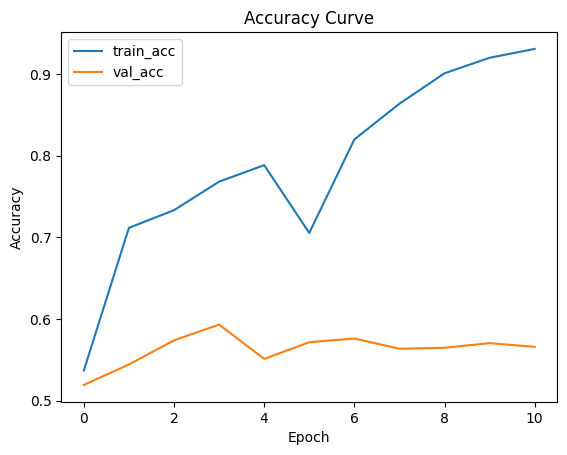

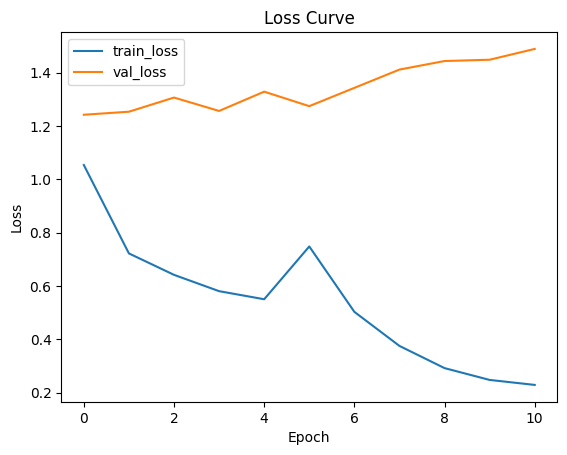

In [ ]:
# 11) Plot Training Curves
def plot_curves(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure()
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(h1, h2)

In [ ]:
# 12) Evaluate on Test
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.5716 | Test Loss: 1.2744


In [ ]:
# 13) Predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 14) Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
                 precision    recall  f1-score   support

    Anthracnose     0.5896    0.4636    0.5191       220
        Healthy     0.5163    0.9364    0.6656       220
           Scab     0.6538    0.2318    0.3423       220
Styler end root     0.6261    0.6545    0.6400       220

       accuracy                         0.5716       880
      macro avg     0.5965    0.5716    0.5417       880
   weighted avg     0.5965    0.5716    0.5417       880



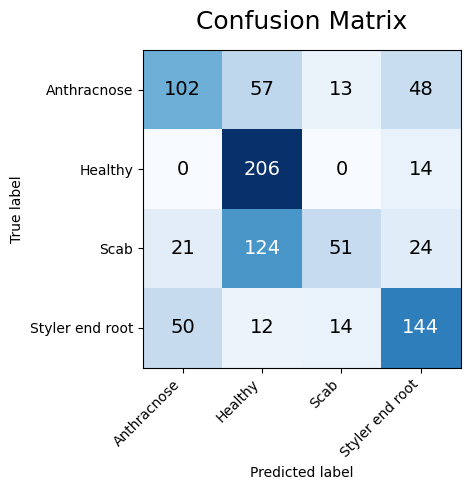

In [ ]:
# 15) Confusion Matrix (Blue style like your image, NO colorbar)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix", fontsize=18, pad=15)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=14, color="white" if cm[i, j] > thresh else "black")

ax.grid(False)
plt.tight_layout()
plt.show()

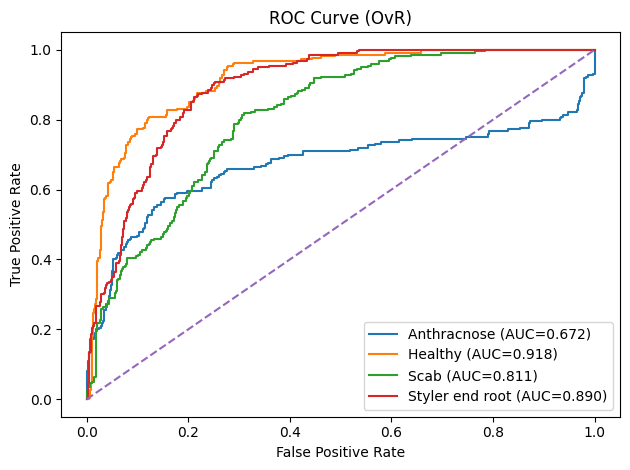

In [ ]:
# 16) ROC Curve (OvR)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 17) Save Model
import os
os.makedirs("/content/drive/MyDrive/Capstone Models", exist_ok=True)

model.save("/content/drive/MyDrive/Capstone Models/ResNet50V2_fruit.keras")
print("Model saved successfully.")

Model saved successfully.
